# Cosmology with GWs/FRBs Associations

In [1]:
import sys
sys.path.append('../../Python_scripts')
sys.path.append('../FRB_cosmo/FRB_cosmo/interpolation')

## Import packages
from config import *
from support import *
from cosmo_support import *

### MCMCM packages
path='../FRB_cosmo/interpolation/095_C0mean.npz' # './interpolation/StandardD_C0mean.npz' 

import mcmc_support_GW_FRB_DM_ext
mcmc_support_GW_FRB_DM_ext.DATA_PATH = path
mcmc_support_GW_FRB_DM_ext.reload_with_path(path)
from mcmc_support_GW_FRB_DM_ext import *

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


-------------------------------------------------------------

# Table of Contents <a name="toc"></a>

1. [Basic definitions](#Definitions)
2. [Checking with Wei et al.](#Reproduction_Results_Wei_et_al)
3. [Cosmo inference without redshift - precise distance info](#Precise_distance_info)
4. [Cosmo inference without redshift - uncertain distance info](#Uncertain_distance_info)
5. [Finding the missing baryons with Macquart et al.](#Macquart_paper)

----------------------------------------------

## Basic definitions <a name="Definitions"></a>

We are defining the **luminosity distance**, observed through GWs:

$$
d_L = \frac{(1+z) c}{H_0} \int_0^z \frac{dz}{\sqrt{\Omega_m(1+z)^3+(1-\Omega_m)(1+z)^{3(1+w)}}}.
$$

For a cosmological constant, we have $w=-1$.

We are defining the IGM **dispersion measure (DM)**, based on [[Deng & Zhang, 2014](https://iopscience.iop.org/article/10.1088/2041-8205/783/2/L35/pdf)], eq. (13) and eq. (12) of [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)]:

$$
{\rm DM}_{\rm IGM} = \frac{3 c H_0 \Omega_b f_{\rm IGM}}{8 \pi G m_p} \int_0^z \frac{\chi(z) (1+z) dz}{\sqrt{\Omega_m(1+z)^3+(1-\Omega_m)(1+z)^{3(1+w)}}} 
$$


Assuming redshifts $z<2$, we use $\chi(z) \simeq 7/8$ - this assumes that the Universe is fully ionised at that time. For higher redshifts, the ionisation history of H and He needs to be modelled.

-----------------------------------------

## 2. $D_L$ & $DM_{ext}$ constraints <a name="D_L DM_diff"></a>

**Creation of mock events** (simplified)

We draw some random redshifts from $[z_{\min}, z_{\max}]$. For these, and the fiducial cosmology, we calculate luminosity distances and DMs, and their respective errors. The mock obsersations are based on these but with scatter that follows a guassian distribution, e.g. ${\rm DM}^{\rm obs} = \mathcal{N}({\rm DM}(z, H^f_0, \Omega_m^f, w^f), \sigma_{\rm DM})$.

We then use the redshifts and the $\chi^2$ statistic to put constraints on $\Omega_m$ and $w$.

Return to TOC [here](#toc).

In [2]:
# Find use quadratic function may get negative error in some large redshift

def GW_error_LVK(z, H0, Om, w=-1, order=1):
    if (order==1):
        a0=19.202
        a1=86.773
        dL=luminosity_distance(z, H0, Om, w)
        return (a1*z+a0)*dL
    elif (order==2):
        a0=17.015
        a1=131.750
        a2=-174.911
        dL=luminosity_distance(z, H0, Om, w)
        return (a2*z*z+a1*z+a0)*dL
    else:
        print('Choose order from 1 or 2. Use default instead')
        return sigma_dL(z_val, H0, Om, w=w, method='Wei')
    
def GW_error_CE(z, H0, Om, w=-1, order=2):
    if (order==1):
        a0=9.792
        a1=9.704
        dL=luminosity_distance(z, H0, Om, w)
        return (a1*z+a0)*dL
    elif (order==2):
        a0=7.649
        a1=18.581
        a2=-4.559
        dL=luminosity_distance(z, H0, Om, w)
        return (a2*z*z+a1*z+a0)*dL
    else:
        print('Choose order from 1 or 2. Use default instead')
        return sigma_dL(z_val, H0, Om, w=w, method='Wei')

## Generate events

**For FRB DM, try to use Macquart pdf**

$$ DM=DM_{MW}+DM_{halo}+DM_{IGM}+\frac{DM_{host}+DM_{src}}{1+z}$$

$$ <DM_{diff}>=\frac{3cH_0 \Omega_b }{8\pi G m_p}\int_0^z \frac{f_{IGM}\chi(z')(1+z')dz'}{E(z')}$$

$ p_{host}(DM_{host}|\mu,\sigma_{host})=\frac{1}{\sqrt{2\pi}DM \sigma_{host}}\exp\left[-\frac{(\log DM-\mu)^2}{2\sigma_{host}^2}\right] $

$ p_{diff}(\Delta)=A\Delta^{-\beta}\exp\left(-\frac{(\Delta^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{diff}^2}\right) $

$ \sigma_{diff} $ dominated by physical variance in $DM_{diff}$

$\Delta=DM_{diff}/<DM_{diff}>$

$ \sigma_{diff}(\sigma_{\Delta}(S,z)) $

Which 3D density profile scales as $ \rho \propto r^{-\alpha} $, we have $\beta=(\alpha+1)/(\alpha-1)$

$ \alpha=3$, $\beta=3$ in Macquart paper.

### Load interpolation

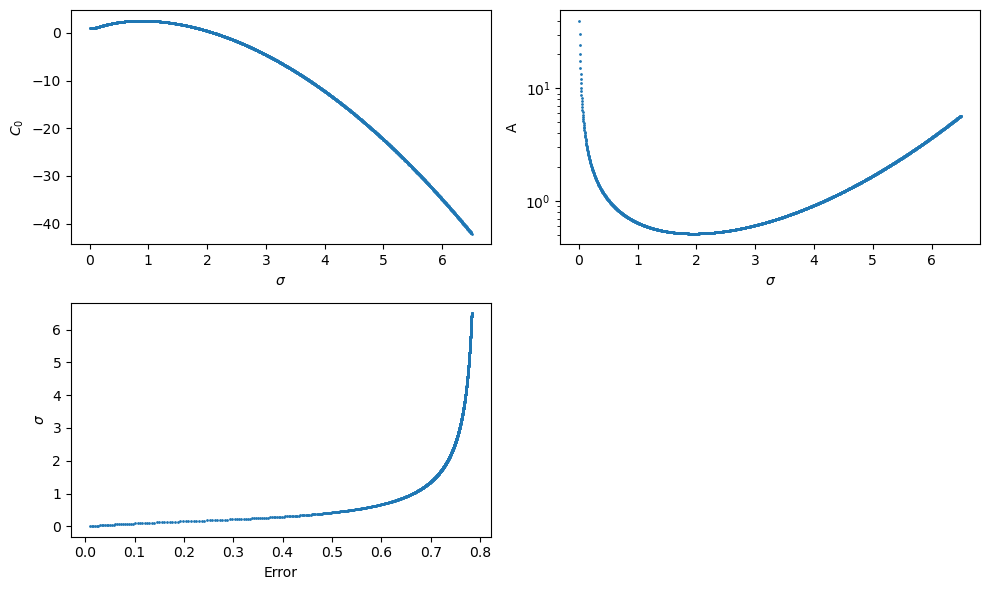

In [3]:
S=0.133
EXP_MU=182.937
SIGMA_HOST=0.605
DM_MWHALO=30
HOF=2.813

fig = plt.figure(figsize=(10, 6))
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)

ax1.scatter(Sigmas, C0s,  s=1)
ax1.set_ylabel(r'$C_0$')
ax1.set_xlabel(r'$\sigma$')

ax2.scatter(Sigmas, As,  s=1)
ax2.set_ylabel('A')
ax2.set_xlabel(r'$\sigma$')
ax2.set_yscale('log')

ax3.scatter(Errors, Sigmas,s=1)
ax3.set_ylabel(r'$\sigma$')
ax3.set_xlabel(r'Error')

plt.tight_layout()
plt.show()

### Cosmological constraints

Now take into account that distances & $DM_{diff}$. To calculate the cosmological parameters, we'll follow a Bayesian approach:

$$
P(\mathbf{H_0}|d_L^{\rm obs}, {\rm DM}^{\rm obs}) \sim \pi(\mathbf{H_0}) \cdot P(d_L^{\rm obs}, {\rm DM}^{\rm obs}|\mathbf{H_0}) = \\
\pi(\mathbf{H_0}) \int dz \ P\left(d_L^{\rm obs}|d_L(z,\mathbf{H_0})\right) \cdot P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0}) \right) \cdot \pi(z)
$$
where with $\mathbf{H_0}$ we denote the _vector_ of cosmological parameters ($H_0, \Omega_m, w$) and $\pi(z)$ is the prior on the redshift distribution of sources and $\pi(\mathbf{H_0})$ the priors on the cosmological parameters. 

For the ${\rm DM}$ part, we can introduce the contributions of different sources as systematic errors and marginalise over them. In reality, we can estimate ${\rm DM}_{\rm diff}$ as:

$$
{\rm DM}_{\rm diff} = {\rm DM}_{\rm obs} - {\rm DM}_{\rm MW} - {\rm DM}_{\rm host}/(1+z), 
$$

where ${\rm DM}_{\rm MW} = {\rm DM}_{\rm MW, halo} + {\rm DM}_{\rm MW, ISM}$. So we can write $P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0}) \right)$ as:

$$
P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0}) \right) = \int d{\rm DM}^{\rm MW} d{\rm DM}^{\rm HG} \pi({\rm DM}^{\rm MW}) \pi({\rm DM}^{\rm HG}) P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0}), {\rm DM}^{\rm MW}, {\rm DM}^{\rm HG} \right).
$$

We infer:

- $H_0$ with $\Omega_m, w$ fixed to their fiducial values
- $H_0, \Omega_m$ with $w$ fixed to its fiducial value
- $H_0, \Omega_m, w$

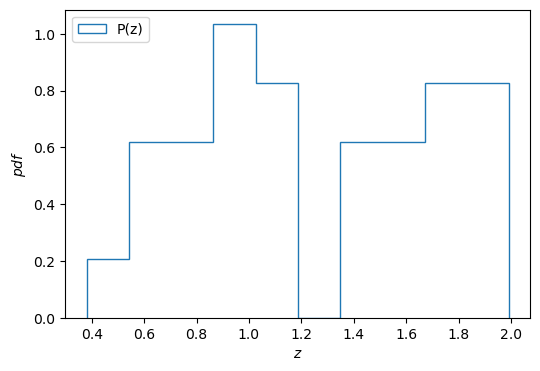

In [4]:
fig = plt.figure(figsize=(6,4))
ax1 = fig.add_subplot(111)

ax1.hist(z_centre, density=True, histtype='step', label='P(z)')
# ax1.hist(Uniform_z_array, density=True, histtype='step', label='Uni')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$pdf$')
ax1.legend(loc='upper left', fontsize=10)

plt.show()

In [5]:
print(f"z={z_centre}")

z=[1.52024048 0.48496994 0.93587174 0.8997996  1.31102204 0.99358717
 0.86733467 1.67174349 0.70501002 1.1991984  1.90260521 0.36593186
 0.93587174 0.61122244 1.56713427 0.27935872 0.61482966 1.08737475
 1.40841683 1.23166333]


In [6]:
print(f"dL={dL_centre} Mpc, DM={DM_centre} pc/cm^3")

dL=[11392.32990504  2816.48592516  6264.51077873  5968.68536691
  9493.02364921  6743.75304432  5704.990501   12803.15616907
  4426.03995068  8504.48580822 15002.18328295  2018.78358881
  6264.51077873  3720.69270365 11826.04647322  1477.06216572
  3747.31909604  7537.07286887 10369.59605697  8789.40266448] Mpc, DM=[1379.32276187  432.26103085  853.61765627  820.16492509 1195.03985277
  906.94833302  789.98552722 1509.79813853  638.3128066  1094.65506002
 1703.80043341  321.87645714  853.61765627  550.38347978 1419.97673358
  242.74482074  553.76522013  993.04044054 1281.41180088 1123.92963882] pc/cm^3


In [7]:
## Choice of observed luminosity distance
sigma_dL = 0.1*dL_centre
dL_obs_centre = np.random.normal(dL_centre, sigma_dL)

DM_obs_centre=np.zeros_like(z_centre)
s_DM_obs = np.zeros_like(z_centre)

for idx, z_val in enumerate(z_centre):
    DM_obs_centre[idx], s_DM_obs[idx] = DM_ext_sampling(z=z_val, 
                                                       S=S, HOF=HOF, SIGMA_HOST=SIGMA_HOST, EXP_MU=EXP_MU,
                                                       sigma_error_inter=sigma_error_inter,
                                                       C0_sigma_inter=C0_sigma_inter,
                                                       A_sigma_inter=A_sigma_inter,
                                                       Om=OMEGA_MATTER, w=W_LAMBDA, N_draws=1, int_N=2000
                                                       )

# print(f"dL_obs={dL_obs_centre} Mpc, DM_obs={DM_obs_centre} pc/cm^3")

/tmp/ipykernel_8182/865709122.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  DM_obs_centre[idx], s_DM_obs[idx] = DM_ext_sampling(z=z_val,


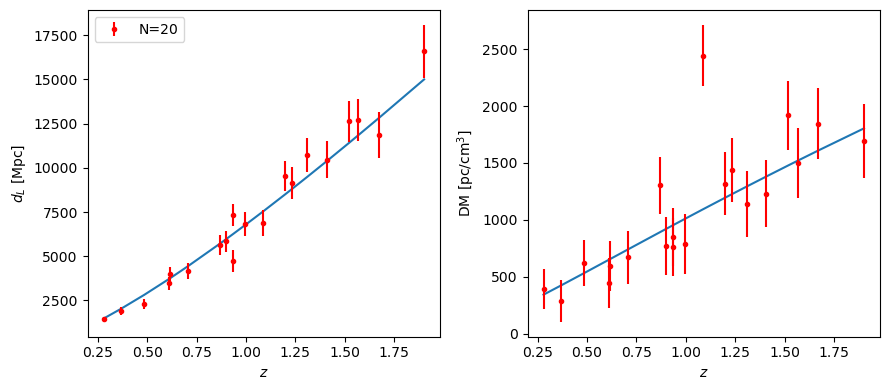

In [8]:
fig = plt.figure(figsize=(9, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(np.sort(z_centre), np.sort(dL_centre))
ax1.errorbar(z_centre, dL_obs_centre, yerr=sigma_dL, marker='o', ls='', ms=3, c='r', label=f'N={len(z_centre)}')
ax1.set_ylabel(r'$d_{L}$ [Mpc]')
ax1.set_xlabel(r'$z$')
ax1.legend(loc='upper left')

ax2.plot(np.sort(z_centre), np.sort(DM_centre)+100)
ax2.errorbar(z_centre, DM_obs_centre, yerr=s_DM_obs, marker='o', ls='', ms=3, c='r')
ax2.set_ylabel(r'DM [pc/cm$^3$]')
ax2.set_xlabel(r'$z$')

plt.tight_layout()
plt.show()

plot KDE, one event as an example

In [9]:
## Creating the posteriors around the observed values
zdx = 0

dL_gaussian = np.random.normal(dL_obs_centre[zdx], sigma_dL[zdx], 1000)

## Here we are imposing a hard cut
dL_gaussian[dL_gaussian<0]=0

## Fitting KDEs around the observed events
GW_dL_kde = gaussian_kde(dL_gaussian)

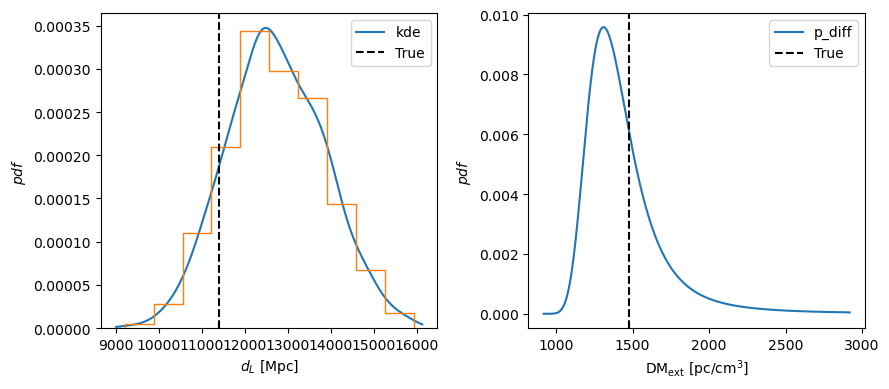

In [10]:
dl_array=np.linspace(np.min(dL_gaussian)-200, np.max(dL_gaussian)+200, 500)
# DM_array=np.linspace(np.min(DM_gaussian)-200, np.max(DM_gaussian)+200, 500)
DM_array=np.linspace(np.max([20,DM_obs_centre[zdx]-1000]), DM_obs_centre[zdx]+1000, 500)

fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(dl_array, GW_dL_kde(dl_array), label='kde')
ax1.hist(dL_gaussian, density=True, histtype='step')
ax1.axvline(x=dL_centre[zdx], ls='--', c='black', label='True')
ax1.set_xlabel(r'$d_L$ [Mpc]')
ax1.set_ylabel(r'$pdf$')
ax1.legend()

p_diff=[
    calculate_dm_probability_num_HOf_fast(dm, z_centre[zdx],
                                     S=S, HOf=HOF, e_mu=EXP_MU, sigma_host=SIGMA_HOST, 
                                     f_sigma_error=sigma_error_inter, 
                                     f_C0_sigma=C0_sigma_inter, f_A_sigma=A_sigma_inter, 
                                     space='Delta',
                                     dropna=False, 
                                     error_calculator=None 
                                     ) for dm in DM_array]
p_diff=normalise(p_diff)
ax2.plot(DM_array, p_diff, label='p_diff')
ax2.axvline(x=DM_centre[zdx]+100, ls='--', c='black', label='True')
ax2.set_xlabel(r'${\rm DM}_{\rm ext}$ [pc/cm$^3$]')
ax2.set_ylabel(r'$pdf$')
# ax2.set_yscale('log')
ax2.legend()

plt.tight_layout()
plt.show()

Now, think about $p_{dL}(z)$ and $p_{\rm DM_{diff}}(z)$

In [11]:
z_array=np.linspace(0.1, 3.0, 500)
lum_distance=luminosity_distance(z=z_array, H0=HUBBLE, Om=OMEGA_MATTER, w=W_LAMBDA)

DMs_z=np.zeros_like(z_array)
for idx, z_val in enumerate(z_array):

    DMs_z[idx]=calculate_dm_probability_num_HOf_fast(DM_obs_centre[zdx], z_val,
                                     S=S, HOf=HOF, e_mu=EXP_MU, sigma_host=SIGMA_HOST, 
                                     f_sigma_error=sigma_error_inter, 
                                     f_C0_sigma=C0_sigma_inter, f_A_sigma=A_sigma_inter, 
                                     space='Delta',
                                     dropna=False, 
                                     error_calculator=None 
                                     )

DMs_z=normalise(DMs_z)

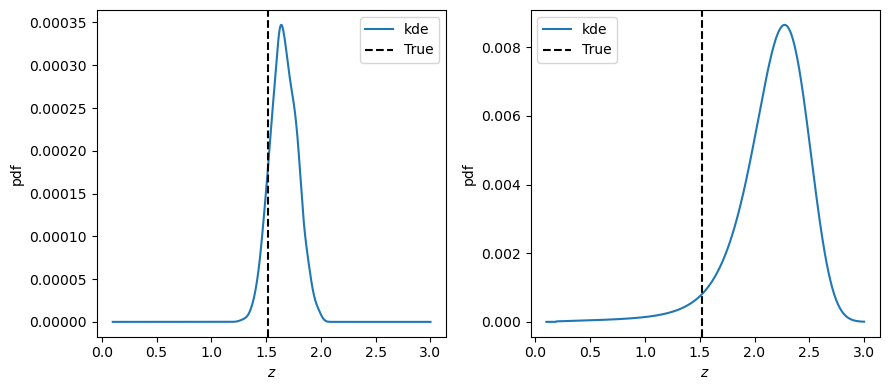

In [12]:
fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(z_array, GW_dL_kde(lum_distance), label='kde')
ax1.axvline(x=z_centre[zdx], ls='--', c='black', label='True')
ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'pdf')
ax1.legend()

ax2.plot(z_array, DMs_z, label='kde')
ax2.axvline(x=z_centre[zdx], ls='--', c='black', label='True')
ax2.set_xlabel(r'$z$')
ax2.set_ylabel(r'pdf')
ax2.legend()

plt.tight_layout()
plt.show()

selection effect

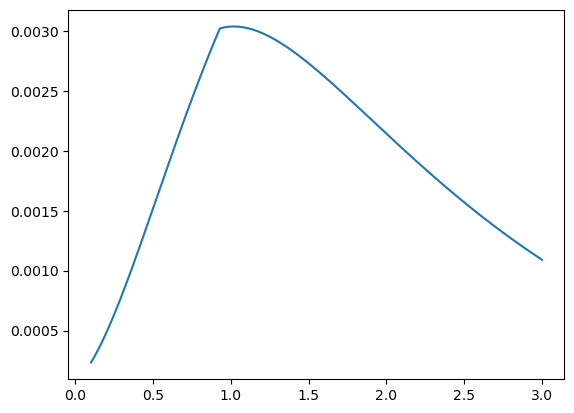

In [13]:
plt.plot(z_array, p_selection, label='P(z)')

In [14]:
events=pd.DataFrame({
    'z': z_centre,
    'dL': dL_centre,
    'dL_obs': dL_obs_centre,
    's_dL': sigma_dL,
    'DM': DM_centre,
    'DM_obs': DM_obs_centre,
    's_DM': s_DM_obs
})
events.head()

,z,dL,dL_obs,s_dL,DM,DM_obs,s_DM
0,1.520240,11392.329905,12627.256554,1139.232991,1379.322762,1919.077002,303.024606
1,0.484970,2816.485925,2318.741002,281.648593,432.261031,623.856047,202.731207
2,0.935872,6264.510779,7343.847072,626.451078,853.617656,758.708967,255.556286
3,0.899800,5968.685367,5840.049954,596.868537,820.164925,769.415719,251.899107
4,1.311022,9493.023649,10737.273120,949.302365,1195.039853,1139.235161,288.260845


In [15]:
# initial parameters
Hubble0 = 70
e_mu0 = 150
sigma_host0 = 0.5

# MCMC parameters
N_WALKERS = 100
HEATING = 10
N_STEPS = 100

In [16]:
# Main execution
if __name__ == "__main__":

    # Define initial parameters: [F, HOf, sigma_host, e_mu]
    initial_params = np.array([Hubble0, e_mu0, sigma_host0])

    # Run MCMC
    sampler = run_mcmc(events, initial_params, nwalkers=N_WALKERS, heating=HEATING, nsteps=N_STEPS)

Running MCMC...
heating...


  0%|          | 0/10 [11:44<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# Analyze results
samples, params_median, params_errors = mcmc_analyze_results(sampler, burn_in=HEATING)

# Print results
param_names = [r'$ H_0$ ', r'$ exp(\mu)$ ', r'$ \sigma_{\rm host}$ ']
print("MCMC Results:")
for i, name in enumerate(param_names):
    print(f"{name} = {params_median[i]:.3f} ± {params_errors[i]:.3f}")

# Save samples to file for later analysis if needed
np.save('./posterior/GW_FRB_MCMC_DM_ext.npy', samples)

MCMC Results:
$ H_0$  = 75.439 ± 13.276
$ exp(\mu)$  = 108.781 ± 85.458
$ \sigma_{\rm host}$  = 0.899 ± 0.481


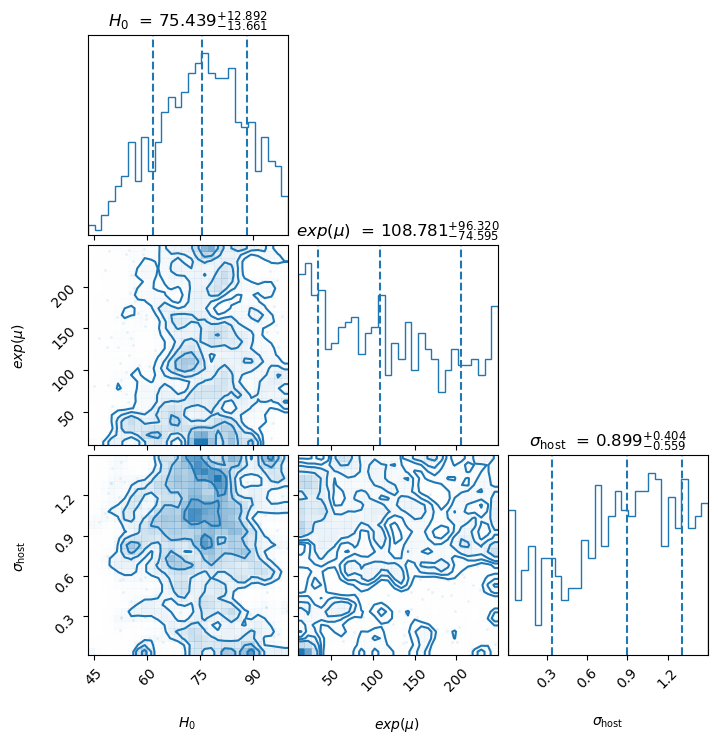

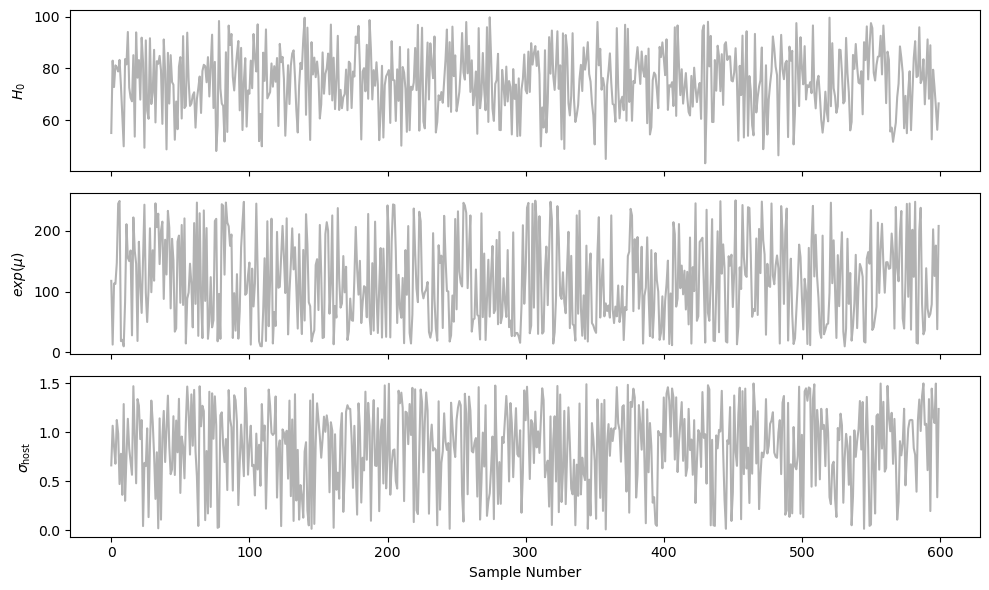

In [ ]:
mcmc_plot_results(samples, param_names, savetitle=None)